# Final Modeling Work for Opioid Project

In [62]:
# Model Development
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from factor_analyzer import FactorAnalyzer

# Data anaysis
import pandas as pd
import numpy as np

# Imbalanced dataset handling by resampling
from collections import Counter
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# Plotting and Correlation Maths
import seaborn as sns
import scipy as sci

# Plotting
import matplotlib.pyplot as plt
import plotly as px


# Data Read (I/O)

In [13]:
# Load the dataset
# file_path = '/Users/hunterberberich/Downloads/cleaned_data_survive.csv' # Hunter's
file_path = '../data/processed/cleaned_data_survive.csv' # Brandon's
data = pd.read_csv(file_path)


# Data Formating

Train/Test Splits

PCA

EFA

Class Balancing: Under, Over, SMOTE

In [24]:

# Preparing the data
X = data.drop(columns=['date', 'survive']).copy()
y = data['survive'].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data for evaluation
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [25]:
# PCA
pca = PCA(n_components=0.95) # Keeps 95% of the variance (cuts down to 9 eigenvector space)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [26]:
# EFA
fa = FactorAnalyzer(n_factors=10, rotation='varimax')
fa.fit(X_train)
X_train_efa = fa.transform(X_train)
X_test_efa = fa.transform(X_test)

In [27]:
# Rebalancing

# Undersample the dataset
nm = NearMiss()
X_train_nm_pca, y_train_nm_pca = nm.fit_resample(X_train_pca, y_train) # PCA resample
X_train_nm_efa, y_train_nm_efa = nm.fit_resample(X_train_efa, y_train) # EFA resample

In [44]:
# Rebalancing

# Oversample the dataset
osp = RandomOverSampler()
X_train_osp_pca, y_train_osp_pca = osp.fit_resample(X_train_pca, y_train) # PCA resample
X_train_osp_efa, y_train_osp_efa = osp.fit_resample(X_train_efa, y_train) # EFA resample

In [46]:
y_train_osp_efa.shape

(4706,)

In [29]:
# Rebalancing

# SMOTE oversampling the dataset (performs interpolation via nearest neighbors)
sm = SMOTE(random_state=42)
X_train_sm_pca, y_train_sm_pca = sm.fit_resample(X_train_pca, y_train)
X_train_sm_efa, y_train_sm_efa = sm.fit_resample(X_train_efa, y_train)


We now have eight possible combinations (PCA, EFA, UnderSampled (PCA&EFA), OverSampled(PCA&EFA), and SMOTE(PCA&EFA)) of data to run.  These can be run through three models (Log Reg, Random Forest, Neural Network).

`Note to team`: There may have been a neat and clever way using sklearn's pipelines to put these all together.  I didn't have the time to dive into that one but if anyone would like to, just for fun or to kill some time at an internship...

https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html#imblearn.pipeline.Pipeline

In [49]:
# Creating lists to loop through

names = ['PCA', 'EFA', 'UnderSample PCA', 'UnderSample EFA', 'OverSample PCA', 'OverSampleEFA',
         'SMOTE PCA', 'SMOTE EFA']

X_train_list = [X_train_pca, X_train_efa, X_train_nm_pca, X_train_nm_efa, X_train_osp_pca, X_train_osp_efa, X_train_sm_pca, X_train_sm_efa]
y_train_list = [y_train, y_train, y_train_nm_pca, y_train_nm_efa, y_train_osp_pca, y_train_osp_efa, y_train_sm_pca, y_train_sm_efa]

X_test_list = [X_test_pca, X_test_efa, X_test_pca, X_test_efa,
               X_test_pca, X_test_efa, X_test_pca, X_test_efa]
y_test_list = [y_test, y_test, y_test, y_test,
               y_test, y_test, y_test, y_test]

In [57]:
# Check to make sure all the shapes are correct and match up
for name, xtrain, ytrain, xtest, ytest in zip(names, X_train_list, y_train_list, X_test_list, y_test_list):

    print(name, xtrain.shape, ytrain.shape, xtest.shape, ytest.shape)

PCA (2788, 16) (2788,) (698, 16) (698,)
EFA (2788, 10) (2788,) (698, 10) (698,)
UnderSample PCA (870, 16) (870,) (698, 16) (698,)
UnderSample EFA (870, 10) (870,) (698, 10) (698,)
OverSample PCA (4706, 16) (4706,) (698, 16) (698,)
OverSampleEFA (4706, 10) (4706,) (698, 10) (698,)
SMOTE PCA (4706, 16) (4706,) (698, 16) (698,)
SMOTE EFA (4706, 10) (4706,) (698, 10) (698,)


# Logistic Regresion

## Balanced Class Weight (only first two tests matter)

PCA Model
Accuracy: 0.5501432664756447
Classification Report:
               precision    recall  f1-score   support

         0.0       0.17      0.48      0.25       109
         1.0       0.85      0.56      0.68       589

    accuracy                           0.55       698
   macro avg       0.51      0.52      0.46       698
weighted avg       0.75      0.55      0.61       698

Confusion Matrix:
 [[ 52  57]
 [257 332]]




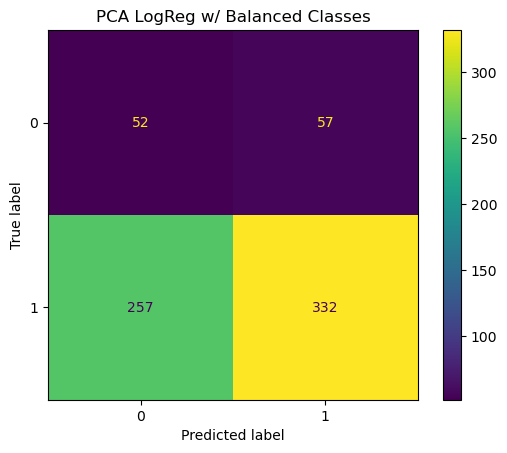

EFA Model
Accuracy: 0.5487106017191977
Classification Report:
               precision    recall  f1-score   support

         0.0       0.17      0.48      0.25       109
         1.0       0.85      0.56      0.68       589

    accuracy                           0.55       698
   macro avg       0.51      0.52      0.46       698
weighted avg       0.75      0.55      0.61       698

Confusion Matrix:
 [[ 52  57]
 [258 331]]




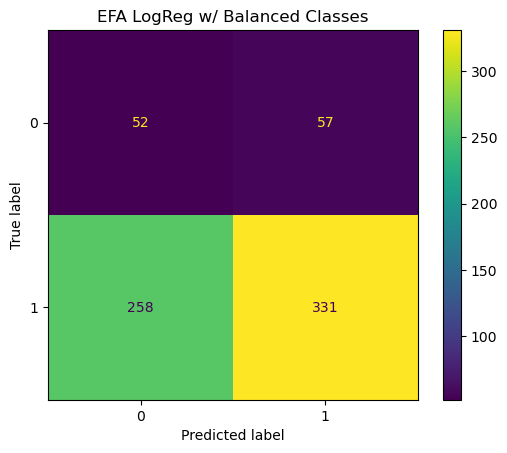

UnderSample PCA Model
Accuracy: 0.39111747851002865
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.63      0.25       109
         1.0       0.84      0.35      0.49       589

    accuracy                           0.39       698
   macro avg       0.49      0.49      0.37       698
weighted avg       0.73      0.39      0.45       698

Confusion Matrix:
 [[ 69  40]
 [385 204]]




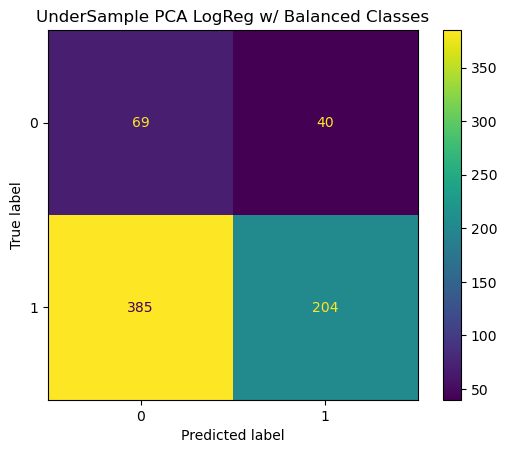

UnderSample EFA Model
Accuracy: 0.40974212034383956
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.60      0.24       109
         1.0       0.83      0.38      0.52       589

    accuracy                           0.41       698
   macro avg       0.49      0.49      0.38       698
weighted avg       0.73      0.41      0.47       698

Confusion Matrix:
 [[ 65  44]
 [368 221]]




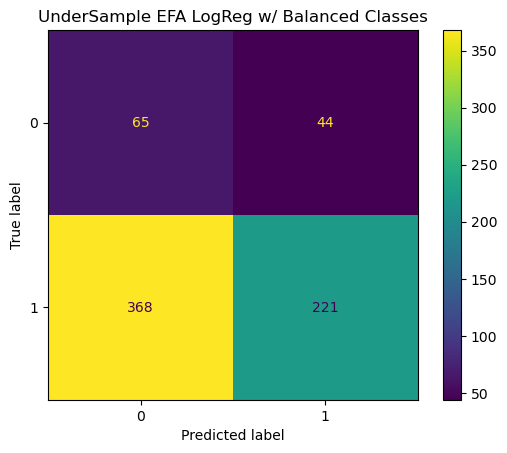

OverSample PCA Model
Accuracy: 0.5730659025787965
Classification Report:
               precision    recall  f1-score   support

         0.0       0.19      0.51      0.27       109
         1.0       0.87      0.58      0.70       589

    accuracy                           0.57       698
   macro avg       0.53      0.55      0.49       698
weighted avg       0.76      0.57      0.63       698

Confusion Matrix:
 [[ 56  53]
 [245 344]]




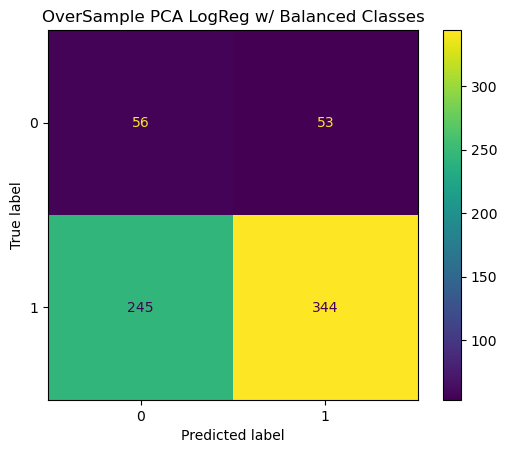

OverSampleEFA Model
Accuracy: 0.5386819484240688
Classification Report:
               precision    recall  f1-score   support

         0.0       0.16      0.46      0.24       109
         1.0       0.85      0.55      0.67       589

    accuracy                           0.54       698
   macro avg       0.50      0.51      0.45       698
weighted avg       0.74      0.54      0.60       698

Confusion Matrix:
 [[ 50  59]
 [263 326]]




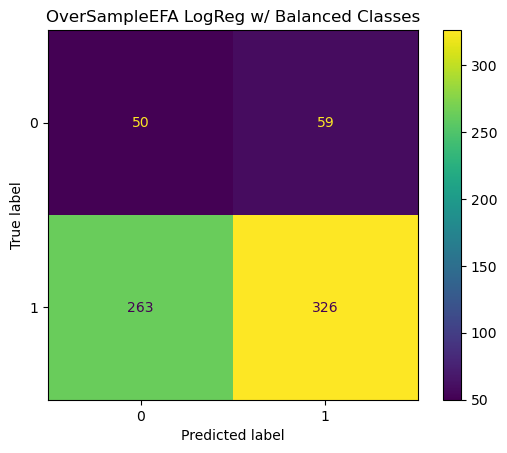

SMOTE PCA Model
Accuracy: 0.5329512893982808
Classification Report:
               precision    recall  f1-score   support

         0.0       0.17      0.51      0.26       109
         1.0       0.86      0.54      0.66       589

    accuracy                           0.53       698
   macro avg       0.51      0.53      0.46       698
weighted avg       0.75      0.53      0.60       698

Confusion Matrix:
 [[ 56  53]
 [273 316]]




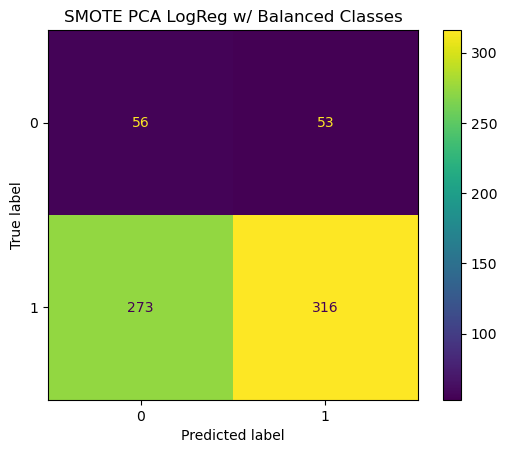

SMOTE EFA Model
Accuracy: 0.5085959885386819
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.47      0.23       109
         1.0       0.84      0.52      0.64       589

    accuracy                           0.51       698
   macro avg       0.50      0.49      0.43       698
weighted avg       0.73      0.51      0.58       698

Confusion Matrix:
 [[ 51  58]
 [285 304]]




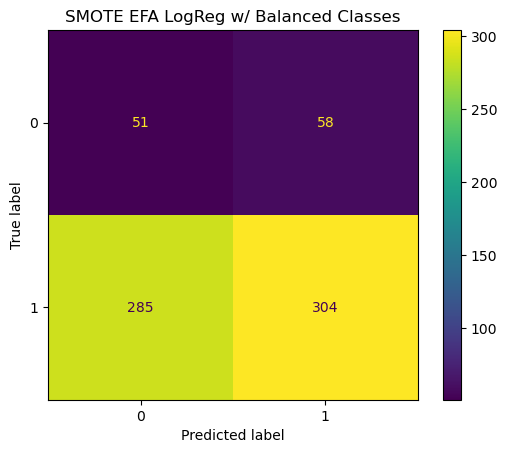

In [71]:
# Using balanced weights (only first two tests matter as last six have sampling built into the data)

performance = []

for name, xtrain, ytrain, xtest, ytest in zip(names, X_train_list, y_train_list, X_test_list, y_test_list):
    # Logistic Regression Setup via sklearn:
    # https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
    log_res = LogisticRegression(class_weight='balanced')
    log_res.fit(xtrain, ytrain)
    log_preds = log_res.predict(xtest) # Will give predictions for your own analysis
    log_res_score = log_res.score(xtest, y_test)
    performance.append((name, accuracy_score(ytest, log_preds), classification_report(ytest,log_preds), confusion_matrix(ytest, log_preds)))


for model_name, accuracy, report, cm in performance:
    print(f"{model_name} Model")
    print("Accuracy:", accuracy)
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    print("\n")

    # Save out a figure of a confusion matrix
    filenameout = '../conf_matrix_figs/' + model_name +'LogRegwBalance'
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(model_name + ' LogReg w/ Balanced Classes')
    plt.savefig(filenameout)
    plt.show()


## No Class weights (All tests matter)

c:\Users\btb51\anaconda3\envs\opioid_env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\btb51\anaconda3\envs\opioid_env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\btb51\anaconda3\envs\opioid_env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

PCA Model
Accuracy: 0.8438395415472779
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       109
         1.0       0.84      1.00      0.92       589

    accuracy                           0.84       698
   macro avg       0.42      0.50      0.46       698
weighted avg       0.71      0.84      0.77       698

Confusion Matrix:
 [[  0 109]
 [  0 589]]




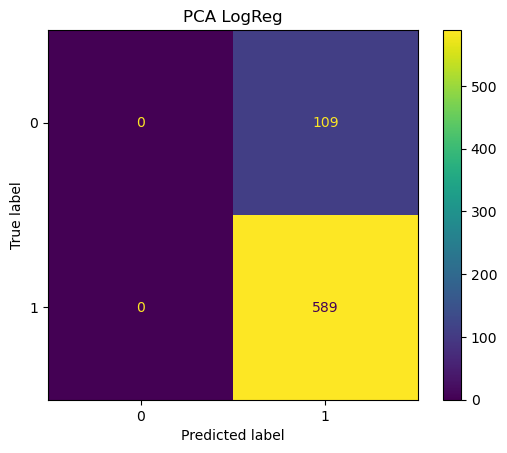

EFA Model
Accuracy: 0.8438395415472779
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       109
         1.0       0.84      1.00      0.92       589

    accuracy                           0.84       698
   macro avg       0.42      0.50      0.46       698
weighted avg       0.71      0.84      0.77       698

Confusion Matrix:
 [[  0 109]
 [  0 589]]




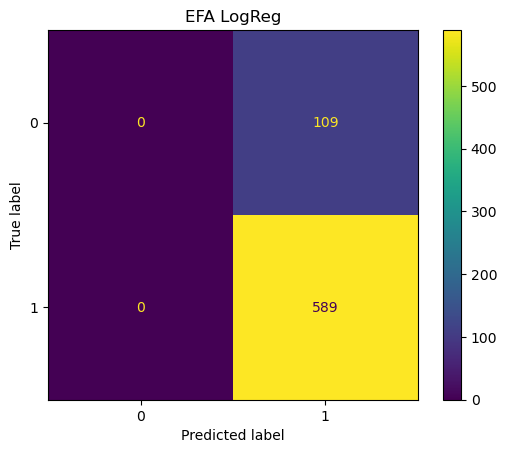

UnderSample PCA Model
Accuracy: 0.39111747851002865
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.63      0.25       109
         1.0       0.84      0.35      0.49       589

    accuracy                           0.39       698
   macro avg       0.49      0.49      0.37       698
weighted avg       0.73      0.39      0.45       698

Confusion Matrix:
 [[ 69  40]
 [385 204]]




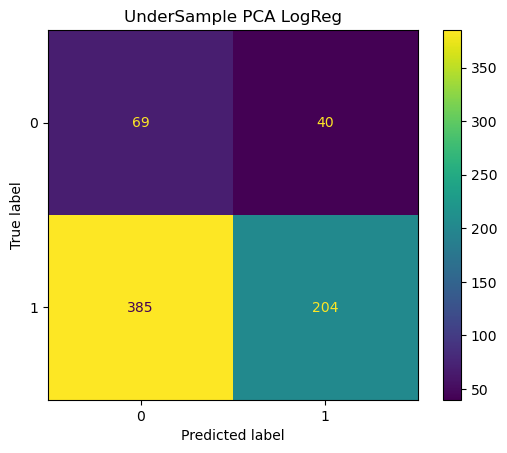

UnderSample EFA Model
Accuracy: 0.40974212034383956
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.60      0.24       109
         1.0       0.83      0.38      0.52       589

    accuracy                           0.41       698
   macro avg       0.49      0.49      0.38       698
weighted avg       0.73      0.41      0.47       698

Confusion Matrix:
 [[ 65  44]
 [368 221]]




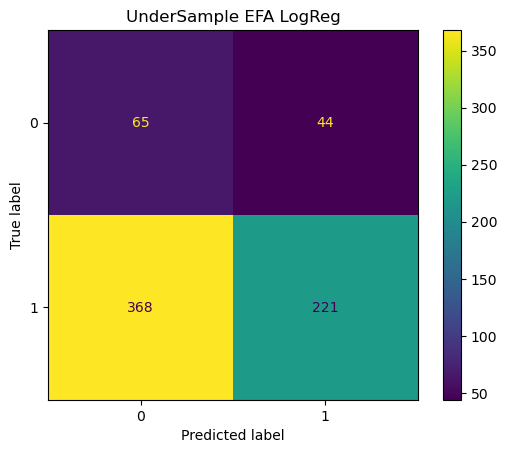

OverSample PCA Model
Accuracy: 0.5730659025787965
Classification Report:
               precision    recall  f1-score   support

         0.0       0.19      0.51      0.27       109
         1.0       0.87      0.58      0.70       589

    accuracy                           0.57       698
   macro avg       0.53      0.55      0.49       698
weighted avg       0.76      0.57      0.63       698

Confusion Matrix:
 [[ 56  53]
 [245 344]]




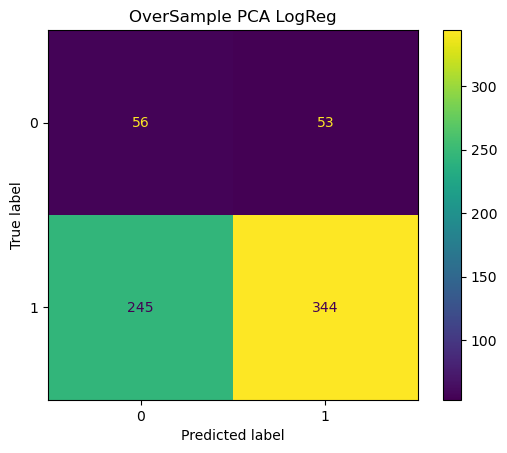

OverSampleEFA Model
Accuracy: 0.5386819484240688
Classification Report:
               precision    recall  f1-score   support

         0.0       0.16      0.46      0.24       109
         1.0       0.85      0.55      0.67       589

    accuracy                           0.54       698
   macro avg       0.50      0.51      0.45       698
weighted avg       0.74      0.54      0.60       698

Confusion Matrix:
 [[ 50  59]
 [263 326]]




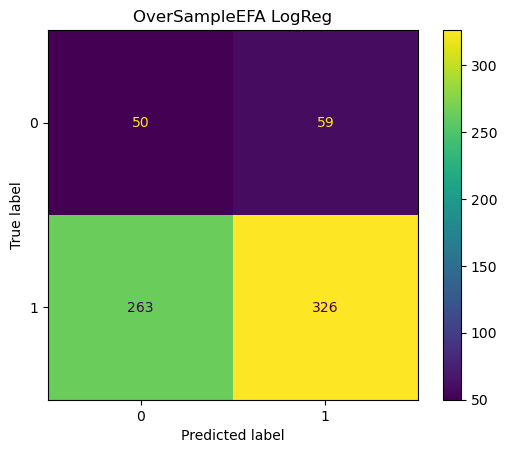

SMOTE PCA Model
Accuracy: 0.5329512893982808
Classification Report:
               precision    recall  f1-score   support

         0.0       0.17      0.51      0.26       109
         1.0       0.86      0.54      0.66       589

    accuracy                           0.53       698
   macro avg       0.51      0.53      0.46       698
weighted avg       0.75      0.53      0.60       698

Confusion Matrix:
 [[ 56  53]
 [273 316]]




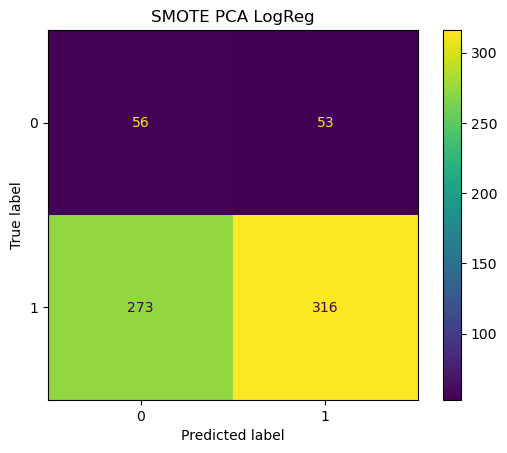

SMOTE EFA Model
Accuracy: 0.5085959885386819
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.47      0.23       109
         1.0       0.84      0.52      0.64       589

    accuracy                           0.51       698
   macro avg       0.50      0.49      0.43       698
weighted avg       0.73      0.51      0.58       698

Confusion Matrix:
 [[ 51  58]
 [285 304]]




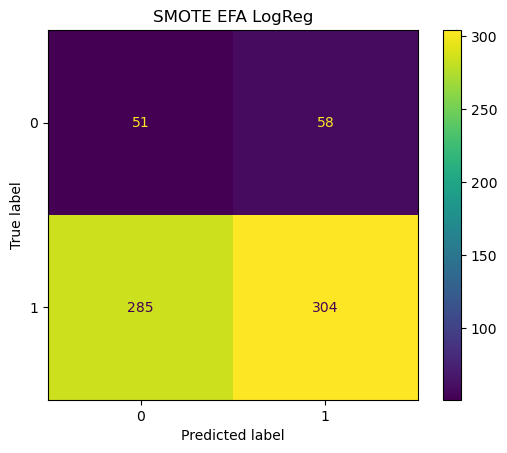

In [72]:
# All tests can be used here as class weights are not assigned.  Class balancing matters!

performance = []

for name, xtrain, ytrain, xtest, ytest in zip(names, X_train_list, y_train_list, X_test_list, y_test_list):
    # Logistic Regression Setup via sklearn:
    # https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
    log_res = LogisticRegression()
    log_res.fit(xtrain, ytrain)
    log_preds = log_res.predict(xtest) # Will give predictions for your own analysis
    log_res_score = log_res.score(xtest, y_test)
    performance.append((name, accuracy_score(ytest, log_preds), classification_report(ytest,log_preds), confusion_matrix(ytest, log_preds)))

for model_name, accuracy, report, cm in performance:
    print(f"{model_name} Model")
    print("Accuracy:", accuracy)
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    print("\n")

    # Save out a figure of a confusion matrix
    filenameout = '../conf_matrix_figs/' + model_name +'LogRegNOBalance'
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(model_name + ' LogReg')
    plt.savefig(filenameout)
    plt.show()

# Random Forest

## Balanced Class Weight (only first two tests matter)

PCA Model
Accuracy: 0.7363896848137536
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.15      0.15       109
         1.0       0.84      0.85      0.84       589

    accuracy                           0.74       698
   macro avg       0.50      0.50      0.50       698
weighted avg       0.73      0.74      0.74       698

Confusion Matrix:
 [[ 16  93]
 [ 91 498]]




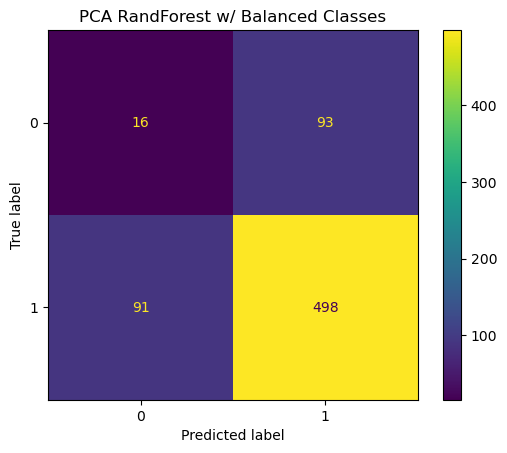

EFA Model
Accuracy: 0.7378223495702005
Classification Report:
               precision    recall  f1-score   support

         0.0       0.14      0.14      0.14       109
         1.0       0.84      0.85      0.85       589

    accuracy                           0.74       698
   macro avg       0.49      0.49      0.49       698
weighted avg       0.73      0.74      0.74       698

Confusion Matrix:
 [[ 15  94]
 [ 89 500]]




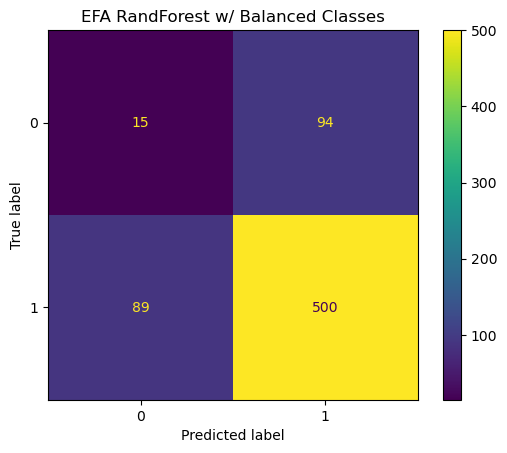

UnderSample PCA Model
Accuracy: 0.27507163323782235
Classification Report:
               precision    recall  f1-score   support

         0.0       0.14      0.72      0.24       109
         1.0       0.79      0.19      0.31       589

    accuracy                           0.28       698
   macro avg       0.46      0.45      0.27       698
weighted avg       0.69      0.28      0.30       698

Confusion Matrix:
 [[ 78  31]
 [475 114]]




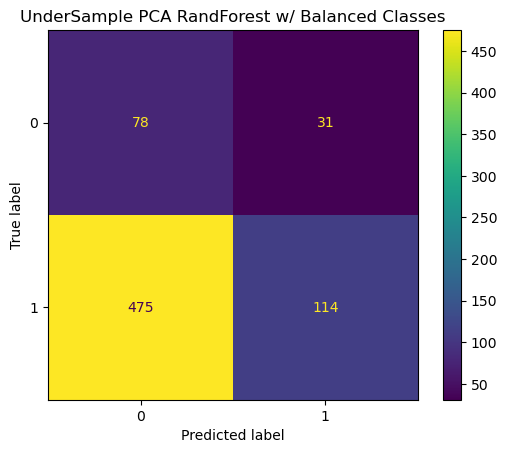

UnderSample EFA Model
Accuracy: 0.2994269340974212
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.74      0.25       109
         1.0       0.82      0.22      0.34       589

    accuracy                           0.30       698
   macro avg       0.48      0.48      0.30       698
weighted avg       0.72      0.30      0.33       698

Confusion Matrix:
 [[ 81  28]
 [461 128]]




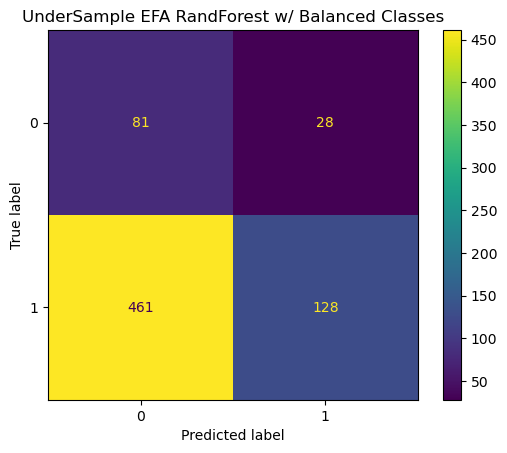

OverSample PCA Model
Accuracy: 0.7091690544412608
Classification Report:
               precision    recall  f1-score   support

         0.0       0.16      0.21      0.18       109
         1.0       0.85      0.80      0.82       589

    accuracy                           0.71       698
   macro avg       0.51      0.51      0.50       698
weighted avg       0.74      0.71      0.72       698

Confusion Matrix:
 [[ 23  86]
 [117 472]]




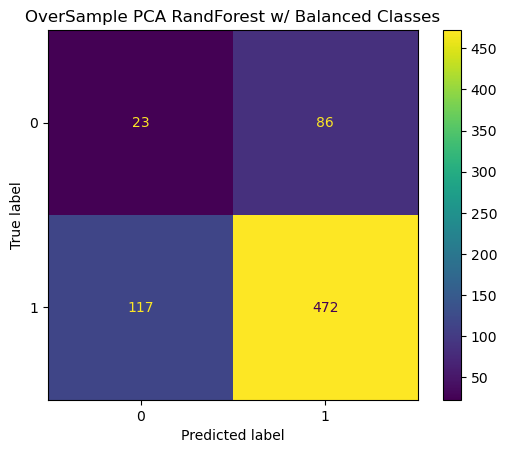

OverSampleEFA Model
Accuracy: 0.7249283667621776
Classification Report:
               precision    recall  f1-score   support

         0.0       0.18      0.21      0.19       109
         1.0       0.85      0.82      0.83       589

    accuracy                           0.72       698
   macro avg       0.51      0.52      0.51       698
weighted avg       0.74      0.72      0.73       698

Confusion Matrix:
 [[ 23  86]
 [106 483]]




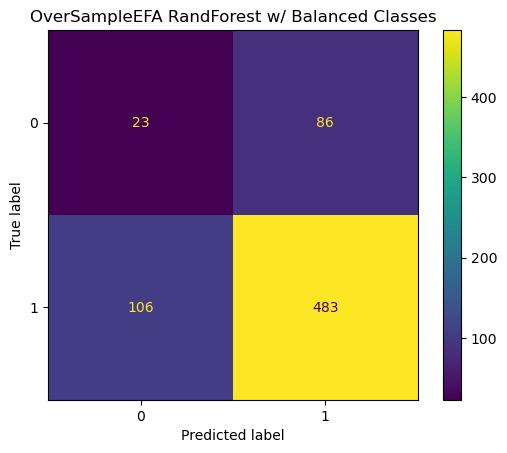

SMOTE PCA Model
Accuracy: 0.6805157593123209
Classification Report:
               precision    recall  f1-score   support

         0.0       0.11      0.16      0.13       109
         1.0       0.83      0.78      0.80       589

    accuracy                           0.68       698
   macro avg       0.47      0.47      0.47       698
weighted avg       0.72      0.68      0.70       698

Confusion Matrix:
 [[ 17  92]
 [131 458]]




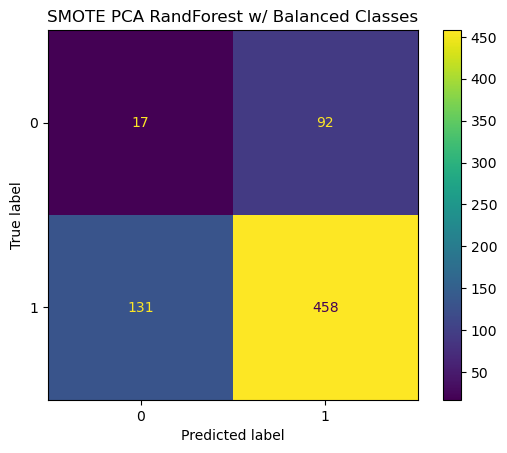

SMOTE EFA Model
Accuracy: 0.6962750716332379
Classification Report:
               precision    recall  f1-score   support

         0.0       0.13      0.17      0.15       109
         1.0       0.84      0.79      0.82       589

    accuracy                           0.70       698
   macro avg       0.49      0.48      0.48       698
weighted avg       0.73      0.70      0.71       698

Confusion Matrix:
 [[ 19  90]
 [122 467]]




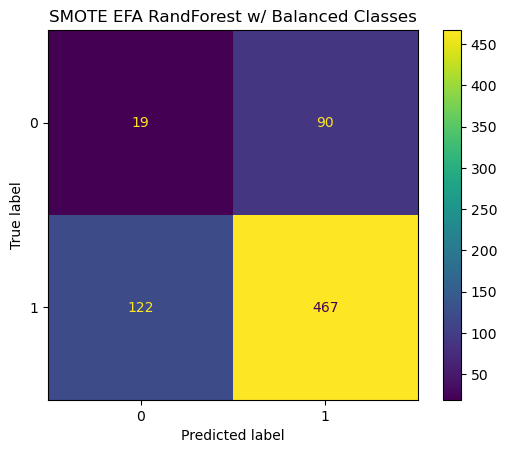

In [73]:
# Using balanced weights (only first two tests matter as last six have sampling built into the data)

performance = []

for name, xtrain, ytrain, xtest, ytest in zip(names, X_train_list, y_train_list, X_test_list, y_test_list):


    # Random Forest Classifier Setup via sklearn:
    # https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
    rf = RandomForestClassifier(n_estimators=100, criterion='entropy', class_weight='balanced') # could use 'gini'
    rf.fit(xtrain, ytrain)
    preds = rf.predict(xtest) # Will give predictions for your own analysis
    rf_score = rf.score(xtest, ytest)  # Will give mean accuracy on the test data and labels
    performance.append((name, accuracy_score(ytest, preds), classification_report(ytest,preds), confusion_matrix(ytest, preds)))



for model_name, accuracy, report, cm in performance:
    print(f"{model_name} Model")
    print("Accuracy:", accuracy)
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    print("\n")

    # Save out a figure of a confusion matrix
    filenameout = '../conf_matrix_figs/' + model_name +'RFwBalance'
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(model_name + ' RandForest w/ Balanced Classes')
    plt.savefig(filenameout)
    plt.show()

## No Class weights (All tests matter)

PCA Model
Accuracy: 0.7879656160458453
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.07      0.10       109
         1.0       0.84      0.92      0.88       589

    accuracy                           0.79       698
   macro avg       0.49      0.50      0.49       698
weighted avg       0.73      0.79      0.76       698

Confusion Matrix:
 [[  8 101]
 [ 47 542]]




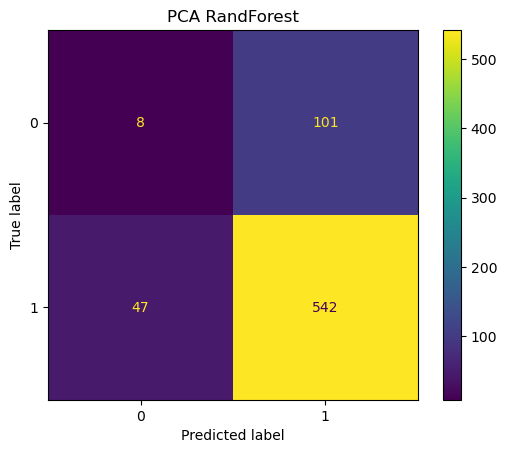

EFA Model
Accuracy: 0.7908309455587392
Classification Report:
               precision    recall  f1-score   support

         0.0       0.14      0.06      0.09       109
         1.0       0.84      0.93      0.88       589

    accuracy                           0.79       698
   macro avg       0.49      0.49      0.48       698
weighted avg       0.73      0.79      0.76       698

Confusion Matrix:
 [[  7 102]
 [ 44 545]]




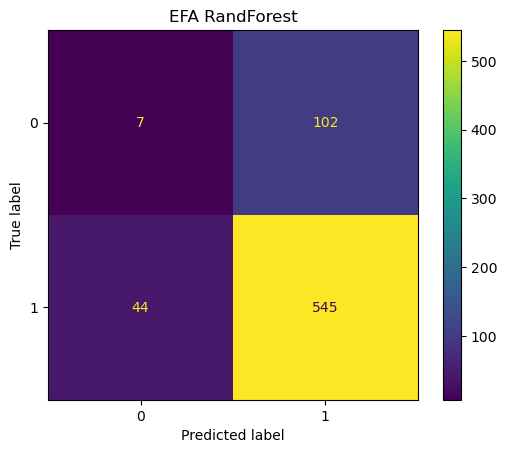

UnderSample PCA Model
Accuracy: 0.27793696275071633
Classification Report:
               precision    recall  f1-score   support

         0.0       0.14      0.72      0.24       109
         1.0       0.79      0.20      0.31       589

    accuracy                           0.28       698
   macro avg       0.47      0.46      0.28       698
weighted avg       0.69      0.28      0.30       698

Confusion Matrix:
 [[ 79  30]
 [474 115]]




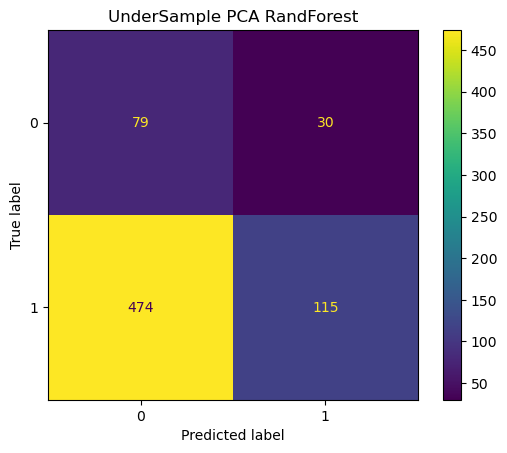

UnderSample EFA Model
Accuracy: 0.29083094555873923
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.72      0.24       109
         1.0       0.81      0.21      0.33       589

    accuracy                           0.29       698
   macro avg       0.48      0.47      0.29       698
weighted avg       0.70      0.29      0.32       698

Confusion Matrix:
 [[ 79  30]
 [465 124]]




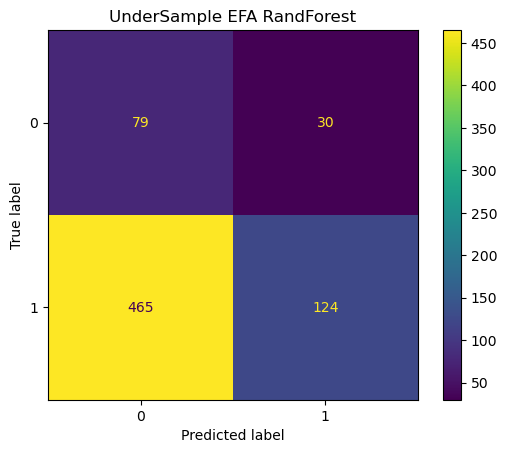

OverSample PCA Model
Accuracy: 0.7106017191977078
Classification Report:
               precision    recall  f1-score   support

         0.0       0.17      0.21      0.19       109
         1.0       0.85      0.80      0.82       589

    accuracy                           0.71       698
   macro avg       0.51      0.51      0.50       698
weighted avg       0.74      0.71      0.72       698

Confusion Matrix:
 [[ 23  86]
 [116 473]]




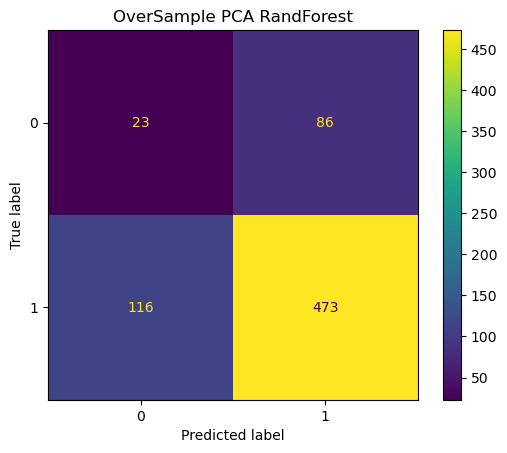

OverSampleEFA Model
Accuracy: 0.7220630372492837
Classification Report:
               precision    recall  f1-score   support

         0.0       0.17      0.20      0.18       109
         1.0       0.85      0.82      0.83       589

    accuracy                           0.72       698
   macro avg       0.51      0.51      0.51       698
weighted avg       0.74      0.72      0.73       698

Confusion Matrix:
 [[ 22  87]
 [107 482]]




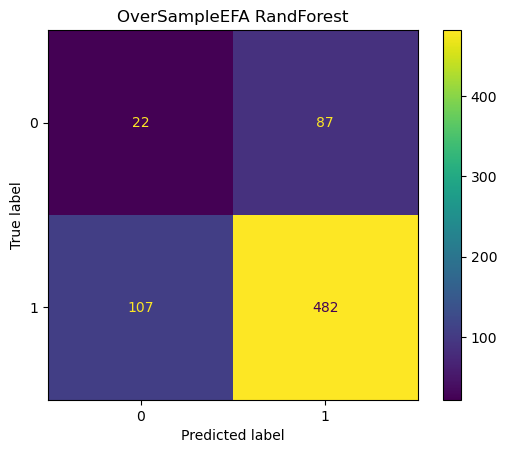

SMOTE PCA Model
Accuracy: 0.6919770773638968
Classification Report:
               precision    recall  f1-score   support

         0.0       0.13      0.17      0.14       109
         1.0       0.84      0.79      0.81       589

    accuracy                           0.69       698
   macro avg       0.48      0.48      0.48       698
weighted avg       0.73      0.69      0.71       698

Confusion Matrix:
 [[ 18  91]
 [124 465]]




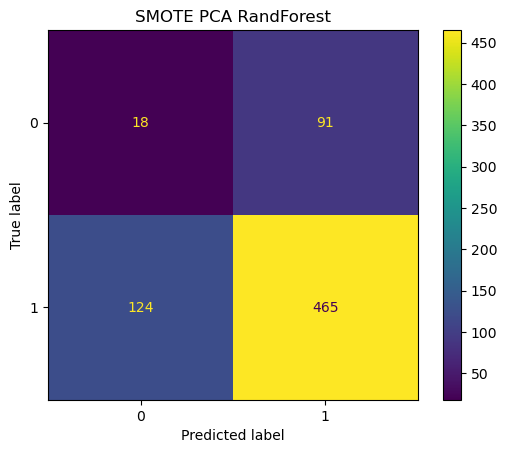

SMOTE EFA Model
Accuracy: 0.7034383954154728
Classification Report:
               precision    recall  f1-score   support

         0.0       0.14      0.18      0.16       109
         1.0       0.84      0.80      0.82       589

    accuracy                           0.70       698
   macro avg       0.49      0.49      0.49       698
weighted avg       0.73      0.70      0.72       698

Confusion Matrix:
 [[ 20  89]
 [118 471]]




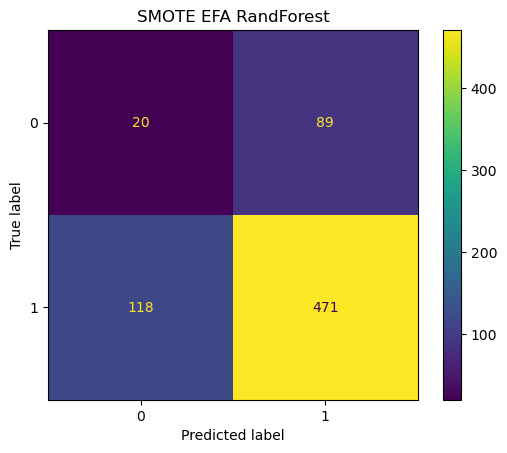

In [74]:
# All tests matter as no class weights are set.  Class balancing matters!

performance = []

for name, xtrain, ytrain, xtest, ytest in zip(names, X_train_list, y_train_list, X_test_list, y_test_list):

    # Random Forest Classifier Setup via sklearn:
    # https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
    rf = RandomForestClassifier(n_estimators=100, criterion='entropy') # could use 'gini'
    rf.fit(xtrain, ytrain)
    preds = rf.predict(xtest) # Will give predictions for your own analysis
    rf_score = rf.score(xtest, ytest)  # Will give mean accuracy on the test data and labels
    performance.append((name, accuracy_score(ytest, preds), classification_report(ytest,preds), confusion_matrix(ytest, preds)))



for model_name, accuracy, report, cm in performance:
    print(f"{model_name} Model")
    print("Accuracy:", accuracy)
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    print("\n")

    # Save out a figure of a confusion matrix
    filenameout = '../conf_matrix_figs/' + model_name +'RFNOBalance'
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(model_name + ' RandForest')
    plt.savefig(filenameout)
    plt.show()

# Multi-Layer Perceptron (Fully Connected Neural Network)

## No Class weights (All tests matter)

PCA Model
Accuracy: 0.8008595988538681
Classification Report:
               precision    recall  f1-score   support

         0.0       0.11      0.04      0.05       109
         1.0       0.84      0.94      0.89       589

    accuracy                           0.80       698
   macro avg       0.47      0.49      0.47       698
weighted avg       0.73      0.80      0.76       698

Confusion Matrix:
 [[  4 105]
 [ 34 555]]




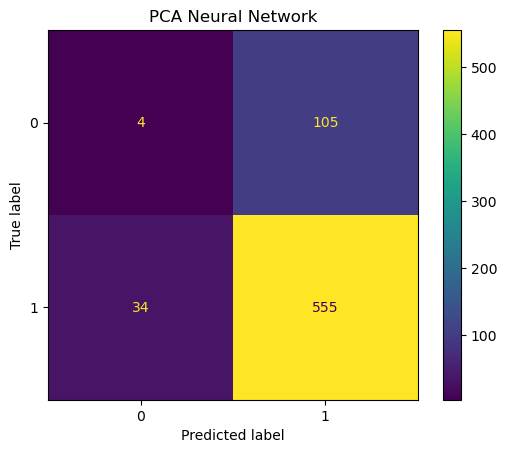

EFA Model
Accuracy: 0.7736389684813754
Classification Report:
               precision    recall  f1-score   support

         0.0       0.10      0.06      0.07       109
         1.0       0.84      0.91      0.87       589

    accuracy                           0.77       698
   macro avg       0.47      0.48      0.47       698
weighted avg       0.72      0.77      0.75       698

Confusion Matrix:
 [[  6 103]
 [ 55 534]]




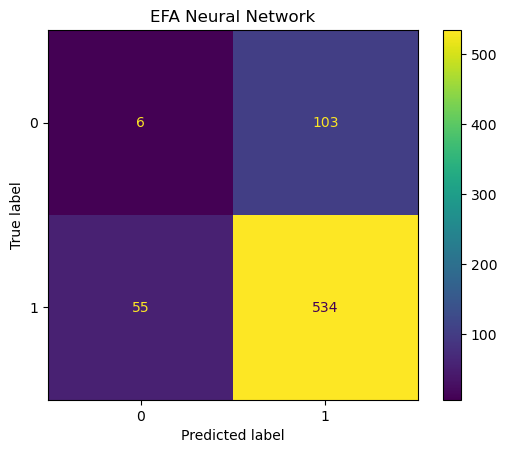

UnderSample PCA Model
Accuracy: 0.3108882521489971
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.72      0.25       109
         1.0       0.82      0.23      0.36       589

    accuracy                           0.31       698
   macro avg       0.49      0.48      0.31       698
weighted avg       0.72      0.31      0.35       698

Confusion Matrix:
 [[ 79  30]
 [451 138]]




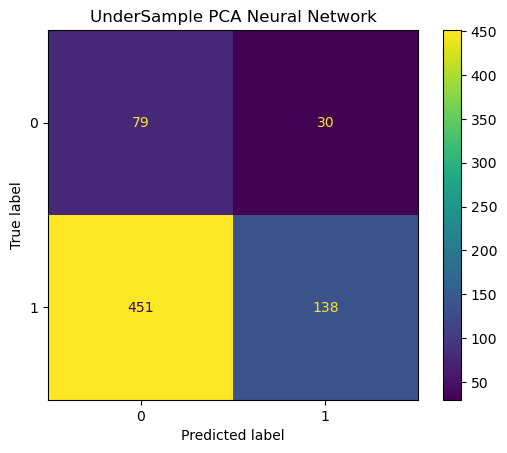

UnderSample EFA Model
Accuracy: 0.34813753581661894
Classification Report:
               precision    recall  f1-score   support

         0.0       0.16      0.73      0.26       109
         1.0       0.85      0.28      0.42       589

    accuracy                           0.35       698
   macro avg       0.50      0.51      0.34       698
weighted avg       0.74      0.35      0.39       698

Confusion Matrix:
 [[ 80  29]
 [426 163]]




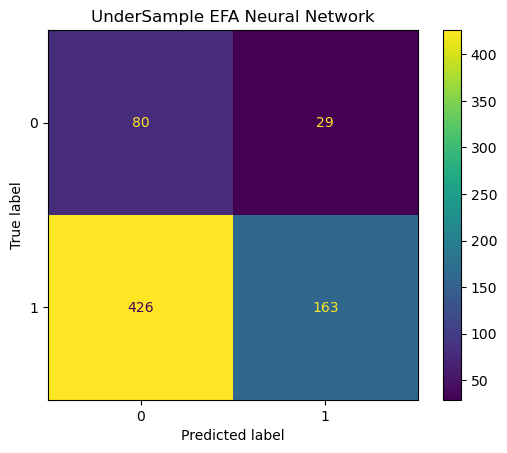

OverSample PCA Model
Accuracy: 0.6303724928366762
Classification Report:
               precision    recall  f1-score   support

         0.0       0.14      0.28      0.19       109
         1.0       0.84      0.70      0.76       589

    accuracy                           0.63       698
   macro avg       0.49      0.49      0.47       698
weighted avg       0.73      0.63      0.67       698

Confusion Matrix:
 [[ 30  79]
 [179 410]]




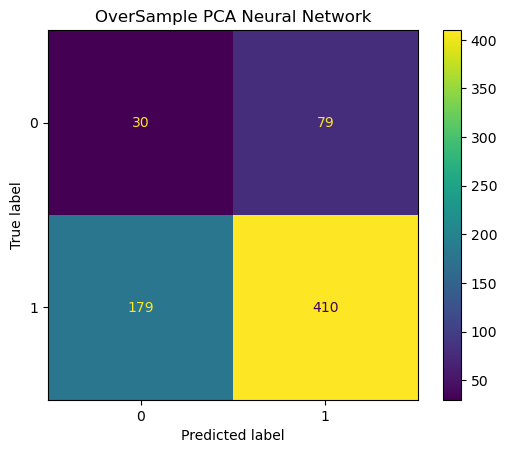

OverSampleEFA Model
Accuracy: 0.6848137535816619
Classification Report:
               precision    recall  f1-score   support

         0.0       0.16      0.25      0.20       109
         1.0       0.85      0.77      0.80       589

    accuracy                           0.68       698
   macro avg       0.50      0.51      0.50       698
weighted avg       0.74      0.68      0.71       698

Confusion Matrix:
 [[ 27  82]
 [138 451]]




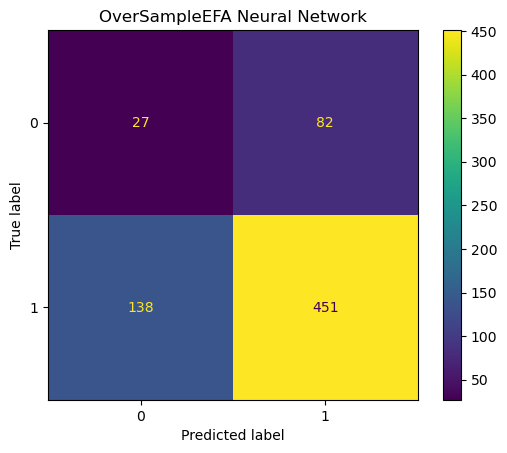

SMOTE PCA Model
Accuracy: 0.6919770773638968
Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.21      0.18       109
         1.0       0.84      0.78      0.81       589

    accuracy                           0.69       698
   macro avg       0.50      0.50      0.49       698
weighted avg       0.73      0.69      0.71       698

Confusion Matrix:
 [[ 23  86]
 [129 460]]




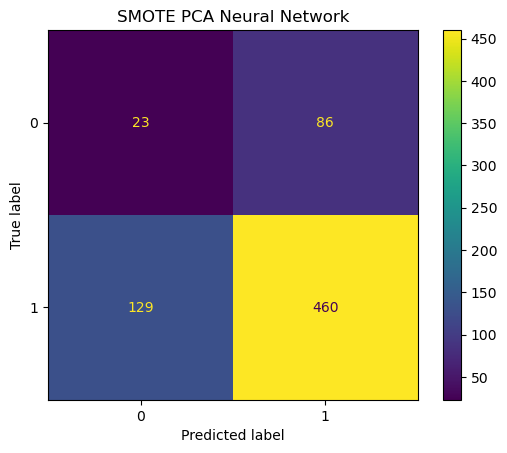

SMOTE EFA Model
Accuracy: 0.6948424068767909
Classification Report:
               precision    recall  f1-score   support

         0.0       0.11      0.14      0.12       109
         1.0       0.83      0.80      0.82       589

    accuracy                           0.69       698
   macro avg       0.47      0.47      0.47       698
weighted avg       0.72      0.69      0.71       698

Confusion Matrix:
 [[ 15  94]
 [119 470]]




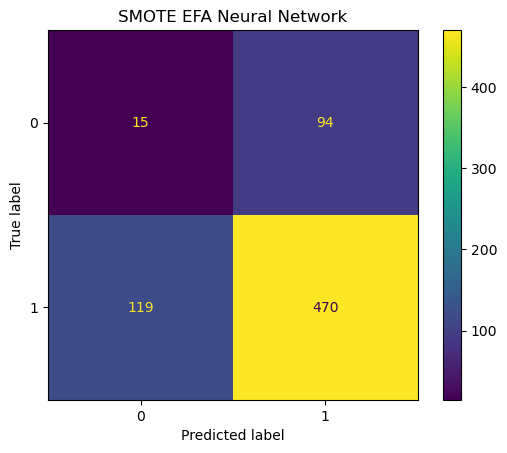

In [75]:
performance = []

for name, xtrain, ytrain, xtest, ytest in zip(names, X_train_list, y_train_list, X_test_list, y_test_list):


    # Neural Network Setup via sklearn: (if you wanted to toss this you could use TensorFlow or PyTorch.  doesn't matter to me)
    # https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
    nn = MLPClassifier(hidden_layer_sizes=(100, 100, 100), activation='relu', solver='adam', max_iter=1000)

    # With undersampled data
    nn.fit(xtrain, ytrain)
    preds = nn.predict(xtest) # Will give predictions for your own analysis
    accuracy = accuracy_score(y_test, preds)
    performance.append((name, accuracy_score(ytest, preds), classification_report(ytest,preds), confusion_matrix(ytest, preds)))

for model_name, accuracy, report, cm in performance:
    print(f"{model_name} Model")
    print("Accuracy:", accuracy)
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    print("\n")

    # Save out a figure of a confusion matrix
    filenameout = '../conf_matrix_figs/' + model_name +'NN'
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(model_name + ' Neural Network')
    plt.savefig(filenameout)
    plt.show()